In [2]:
from imblearn.under_sampling import RandomUnderSampler
from torchvision import transforms
from torchvision.transforms import RandAugment
import torch.nn as nn
import pandas as pd

In [3]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[0]
sys.path.append(str(ROOT))

from Utils.project_utils import get_project_root

In [4]:
PROJECT_ROOT = get_project_root()
CLASSES_DIR = PROJECT_ROOT / "Classes"
DATA_DIR = PROJECT_ROOT / "Data"

In [5]:
near_dedup = pd.read_csv(DATA_DIR / "mushroomDedupNearMerged.csv")

### Data Pipeline & Transformations

#### Standardization

Standardization was applied dynamically during df loading to ensure consistent input format for model training. All images were resized to a fixed input resolution to accommodate convolutional neural network requirements. Pixel values were scaled to the range [0, 1] and normalized using predefined channel-wise mean and standard deviation values. This process was deterministic and applied consistently across training, validation, and test datasets.

#### Augmentation
Data augmentation was applied only to the training dataset to improve model robustness and generalization. Random transformations, including horizontal flipping, rotation, and color jittering, were used to introduce controlled variability in image appearance while preserving semantic content. Augmentation was performed at load time and did not modify the original image files.

In [6]:
IMG_SIZE = 224

# RGB statistics of ImageNet
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# MILDER IMG AUGMENTATION FOR RESNET-18.
train_tfms_mild = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),  # converts to [0,1]
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# MEDIUM IMG AUGMENTATION FOR RESNET-18 (more aggressive than mild, but not as strong as ResNet-50/Swin). 
train_tfms_medium = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1),
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# STRONGER IMG AUGMENTATION FOR RESNET-50 and SWIN.
train_tfms_strong = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),  # stronger jitter
        RandAugment(num_ops=2, magnitude=9),  # learned augmentation policy
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        transforms.RandomErasing(p=0.25),  # CutOut-style regularization
    ]
)

# Run for either model
val_tfms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

##### Balanced Dataset

To mitigate severe class imbalance, we merged the deadly and poisonous classes into a single toxic category and applied undersampling.

In [7]:
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(near_dedup[['file_path']], near_dedup[['class']])

df_balanced = X_res.copy()
df_balanced["class"] = y_res

In [8]:
df_balanced["class"].value_counts()

class
conditionally_edible    16058
edible                  16058
toxic                   16058
Name: count, dtype: int64

In [14]:
df_balanced.to_csv(DATA_DIR / "mushroomBalanced.csv", index=False)

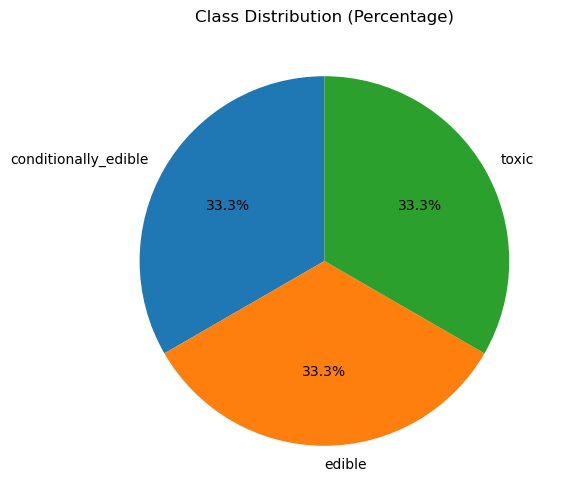

In [11]:
import matplotlib.pyplot as plt

counts = df_balanced["class"].value_counts().sort_index()

plt.figure(figsize=(6, 6))

plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90)

plt.title("Class Distribution (Percentage)")
plt.show()